In [ ]:
import pandas as pd
df = pd.read_csv("gsearch_jobs.csv")

In [10]:
print(df.shape)
print(df.columns.tolist())
print(df.head())
df.info()

(61953, 27)
['Unnamed: 0', 'index', 'title', 'company_name', 'location', 'via', 'description', 'extensions', 'job_id', 'thumbnail', 'posted_at', 'schedule_type', 'work_from_home', 'salary', 'search_term', 'date_time', 'search_location', 'commute_time', 'salary_pay', 'salary_rate', 'salary_avg', 'salary_min', 'salary_max', 'salary_hourly', 'salary_yearly', 'salary_standardized', 'description_tokens']
   Unnamed: 0  index                                             title  \
0           0      0                                      Data Analyst   
1           1      1                                      Data Analyst   
2           2      2                         Aeronautical Data Analyst   
3           3      3  Data Analyst - Consumer Goods - Contract to Hire   
4           4      4               Data Analyst | Workforce Management   

                 company_name            location           via  \
0                        Meta           Anywhere   via LinkedIn   
1                 

In [11]:
df.columns.tolist()

['Unnamed: 0',
 'index',
 'title',
 'company_name',
 'location',
 'via',
 'description',
 'extensions',
 'job_id',
 'thumbnail',
 'posted_at',
 'schedule_type',
 'work_from_home',
 'salary',
 'search_term',
 'date_time',
 'search_location',
 'commute_time',
 'salary_pay',
 'salary_rate',
 'salary_avg',
 'salary_min',
 'salary_max',
 'salary_hourly',
 'salary_yearly',
 'salary_standardized',
 'description_tokens']

In [ ]:
df["title_clean"] = df["title"].str.lower().str.strip()
df["title_clean"] = (
    df["title"]
    .str.lower()
    .str.strip()
    .str.replace(".", "", regex=False)
)
df["title_clean"] = df["title_clean"].replace({
    "sr data analyst": "senior data analyst",
    "sr data analyst marketing operations": "senior data analyst",
})
import numpy as np

df["role_group"] = np.select(
    [
        df["title_clean"].str.contains("data scientist"),
        df["title_clean"].str.contains("data engineer"),
        df["title_clean"].str.contains("business intelligence"),
        df["title_clean"].str.contains("business analyst"),
        df["title_clean"].str.contains("data analyst"),
        df["title_clean"].str.contains("data governance"),
    ],
    [
        "data scientist",
        "data engineer",
        "bi analyst",
        "business analyst",
        "data analyst",
        "data governance analyst",
    ],
    default="other"
)


print(df["role_group"].value_counts().head(20))

In [26]:
df.groupby("role_group")["salary_avg"].agg(["mean", "count"]).sort_values("mean", ascending=False)

,mean,count
role_group,,
data engineer,89067.858000,155
data scientist,85589.742441,424
data governance analyst,68522.032609,46
bi analyst,63436.145045,223
business analyst,50371.546548,126
data analyst,43628.941565,5887
other,29167.305933,3227


In [40]:
value = df["work_from_home"].notna().mean() * 100
print(round(value, 2))

45.16


In [55]:
df_exploded = df.explode("description_tokens")
df_exploded["skill"] = (
    df_exploded["description_tokens"]
    .str.strip()
    .str.lower()
)
skill_counts = (
    df_exploded
    .groupby(["role_group", "skill"])
    .size()
    .reset_index(name="count")
)
top_skills = (
    skill_counts
    .sort_values(["role_group", "count"], ascending=[True, False])
    .groupby("role_group")
    .head(5)
)
top_skills_list = (
    top_skills
    .groupby("role_group")["skill"]
    .apply(list)
    .reset_index()
)
top_skills_list

,role_group,skill
0,bi analyst,"[sql, power_bi, tableau, excel, python]"
1,business analyst,"[sql, excel, power_bi, tableau, ]"
2,data analyst,"[sql, excel, power_bi, tableau, python]"
3,data engineer,"[sql, python, aws, azure, spark]"
4,data governance analyst,"[sql, , excel, power_bi, tableau]"
5,data scientist,"[python, sql, r, tableau, aws]"
6,other,"[sql, , excel, python, power_bi]"


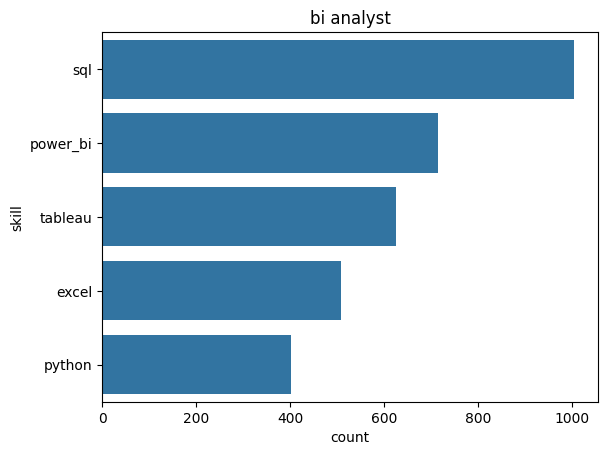

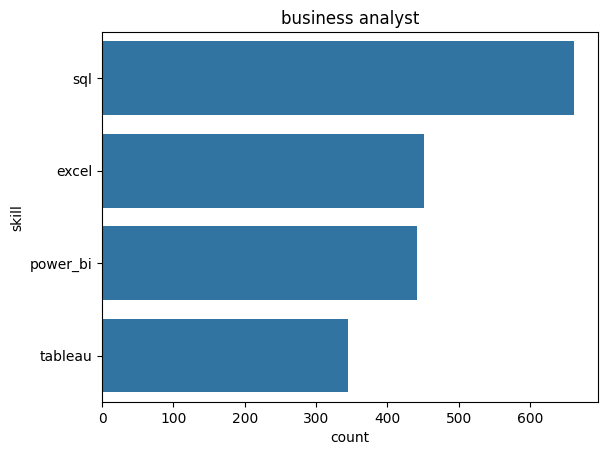

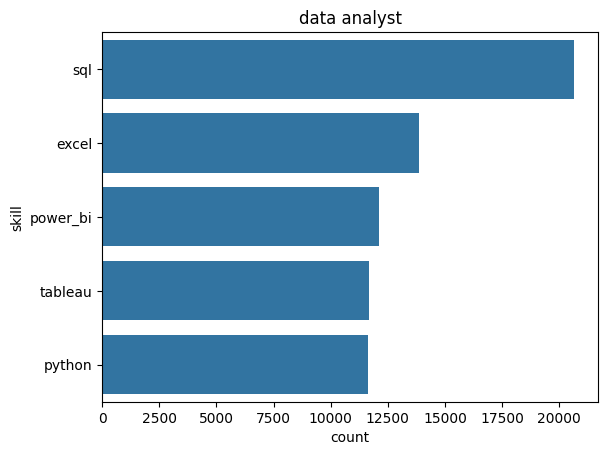

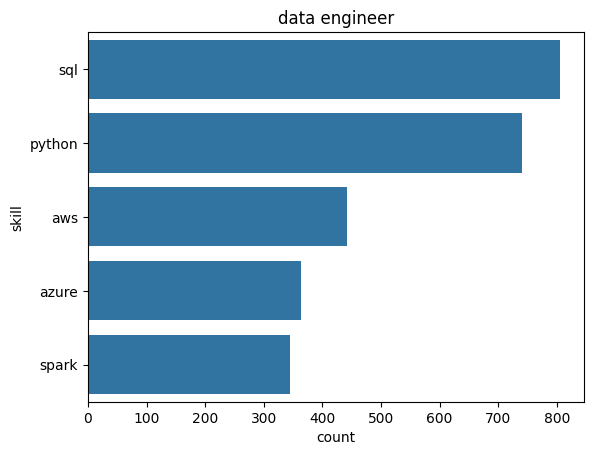

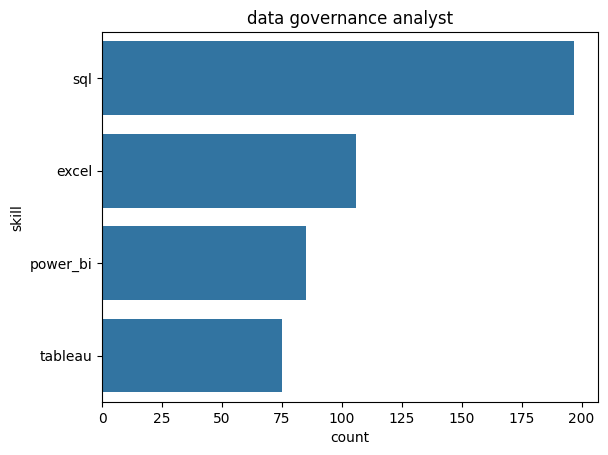

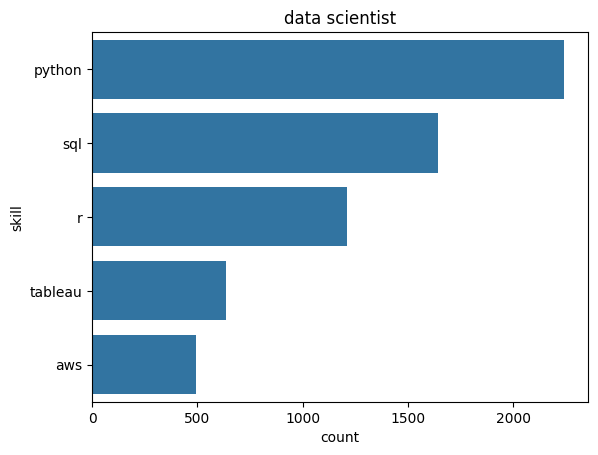

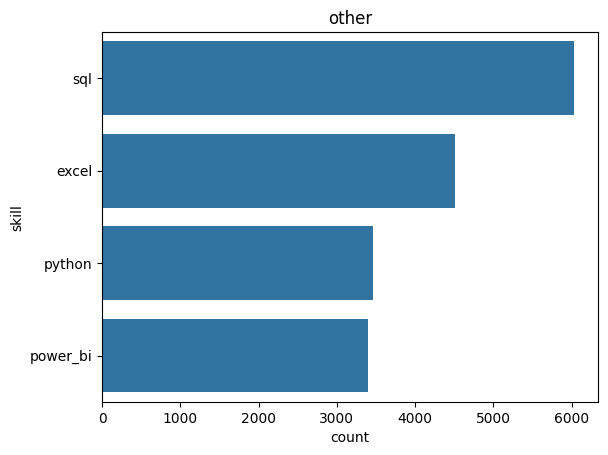

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
roles = top_skills["role_group"].unique()
for role in roles:
    plot_df = top_skills[top_skills["role_group"] == role]
    plot_df = plot_df[plot_df["skill"].notna()]
    plot_df = plot_df[plot_df["skill"].str.strip() != ""]
    sns.barplot(data=plot_df, x="count", y="skill")
    plt.title(role)
    plt.show()